# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The GTA VI Fan Expectation Dataset](https://www.kaggle.com/datasets/uditjain13/gta-6-fan-expectations-and-hype-survey-2026/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/uditjain13/gta-6-fan-expectations-and-hype-survey-2026/gta6_fan_expectations_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('gta6_fan_expectations_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,respondent_id,age,gender,region,primary_platform,favorite_previous_gta,years_following_gta6,primary_info_source,trailer1_times_watched,most_anticipated_feature,hype_score_1to10,confidence_rockstar_delivers_1to5,preorder_intent,willingness_to_pay_usd,expected_firstweek_hours,expects_release_delay,worried_about_price,follows_rockstar_socials,hype_change_vs_6mo_ago,overall_sentiment
0,R100000,30,Male,Europe,Undecided,GTA San Andreas,5,Reddit,13,Better driving physics,10,5,No,96.0,19,Yes,No,Yes,Same,Very Positive
1,R100001,29,Male,Europe,PC,GTA San Andreas,4,X/Twitter,15,Dual protagonists (Jason & Lucia),10,3,Yes,70.0,10,No,No,No,Same,Very Positive
2,R100002,28,Female,Europe,Xbox Series X/S,GTA V,6,YouTube,9,Story & narrative depth,7,5,Maybe,81.0,6,No,No,Yes,Increased,Positive
3,R100003,30,Male,Europe,Xbox Series X/S,GTA Vice City,8,Gaming news sites,6,Online/multiplayer mode,8,4,Yes,80.0,11,Yes,No,Yes,Increased,Very Positive
4,R100004,40,Male,Europe,PlayStation 5,GTA V,10,TikTok,8,Realistic economy & businesses,8,4,No,69.0,25,Yes,Yes,No,Same,Very Positive


## last Five row

In [4]:
df.tail()

,respondent_id,age,gender,region,primary_platform,favorite_previous_gta,years_following_gta6,primary_info_source,trailer1_times_watched,most_anticipated_feature,hype_score_1to10,confidence_rockstar_delivers_1to5,preorder_intent,willingness_to_pay_usd,expected_firstweek_hours,expects_release_delay,worried_about_price,follows_rockstar_socials,hype_change_vs_6mo_ago,overall_sentiment
5995,R105995,15,Male,Asia-Pacific,PlayStation 5,GTA San Andreas,9,Official Rockstar trailer,8,Open-world Vice City map,10,3,Yes,94.0,12,Yes,No,Yes,Same,Very Positive
5996,R105996,22,Male,North America,PC,GTA V,2,Gaming news sites,11,Open-world Vice City map,10,4,Yes,108.0,25,Yes,No,Yes,Increased,Very Positive
5997,R105997,36,Male,North America,PlayStation 5,GTA IV,1,TikTok,4,Deeper character customization,8,3,Yes,68.0,17,Yes,No,Yes,Increased,Very Positive
5998,R105998,13,Non-binary,Europe,PlayStation 5,GTA Vice City,1,X/Twitter,5,Open-world Vice City map,7,2,Yes,43.0,12,Yes,No,Yes,Same,Positive
5999,R105999,20,Male,Europe,PC,GTA Vice City,8,YouTube,11,Dual protagonists (Jason & Lucia),9,4,Yes,75.0,52,No,No,No,Increased,Very Positive


## Shape of our dataset

In [5]:
df.shape

(6000, 20)

## List out all columns

In [6]:
df.columns

Index(['respondent_id', 'age', 'gender', 'region', 'primary_platform',
       'favorite_previous_gta', 'years_following_gta6', 'primary_info_source',
       'trailer1_times_watched', 'most_anticipated_feature',
       'hype_score_1to10', 'confidence_rockstar_delivers_1to5',
       'preorder_intent', 'willingness_to_pay_usd', 'expected_firstweek_hours',
       'expects_release_delay', 'worried_about_price',
       'follows_rockstar_socials', 'hype_change_vs_6mo_ago',
       'overall_sentiment'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

respondent_id                         object
age                                    int64
gender                                object
region                                object
primary_platform                      object
favorite_previous_gta                 object
years_following_gta6                   int64
primary_info_source                   object
trailer1_times_watched                 int64
most_anticipated_feature              object
hype_score_1to10                       int64
confidence_rockstar_delivers_1to5      int64
preorder_intent                       object
willingness_to_pay_usd               float64
expected_firstweek_hours               int64
expects_release_delay                 object
worried_about_price                   object
follows_rockstar_socials              object
hype_change_vs_6mo_ago                object
overall_sentiment                     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   respondent_id                      6000 non-null   object 
 1   age                                6000 non-null   int64  
 2   gender                             5940 non-null   object 
 3   region                             6000 non-null   object 
 4   primary_platform                   6000 non-null   object 
 5   favorite_previous_gta              6000 non-null   object 
 6   years_following_gta6               6000 non-null   int64  
 7   primary_info_source                6000 non-null   object 
 8   trailer1_times_watched             6000 non-null   int64  
 9   most_anticipated_feature           6000 non-null   object 
 10  hype_score_1to10                   6000 non-null   int64  
 11  confidence_rockstar_delivers_1to5  6000 non-null   int64

## Check Null Value

In [9]:
df.isnull().sum()

respondent_id                          0
age                                    0
gender                                60
region                                 0
primary_platform                       0
favorite_previous_gta                  0
years_following_gta6                   0
primary_info_source                    0
trailer1_times_watched                 0
most_anticipated_feature               0
hype_score_1to10                       0
confidence_rockstar_delivers_1to5      0
preorder_intent                        0
willingness_to_pay_usd               120
expected_firstweek_hours               0
expects_release_delay                  0
worried_about_price                    0
follows_rockstar_socials               0
hype_change_vs_6mo_ago                 0
overall_sentiment                      0
dtype: int64

# Drop Null Features

In [10]:
df.drop(columns=['gender', 'willingness_to_pay_usd'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,years_following_gta6,trailer1_times_watched,hype_score_1to10,confidence_rockstar_delivers_1to5,expected_firstweek_hours
count,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,26.12050,6.030833,8.785333,7.777500,3.700667,16.451000
std,7.66521,2.911751,3.032675,1.797832,0.970854,11.491937
min,13.00000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,20.00000,4.000000,7.000000,7.000000,3.000000,8.000000
50%,26.00000,6.000000,9.000000,8.000000,4.000000,14.000000
75%,31.00000,8.000000,11.000000,9.000000,4.000000,22.000000
max,59.00000,13.000000,20.000000,10.000000,5.000000,101.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

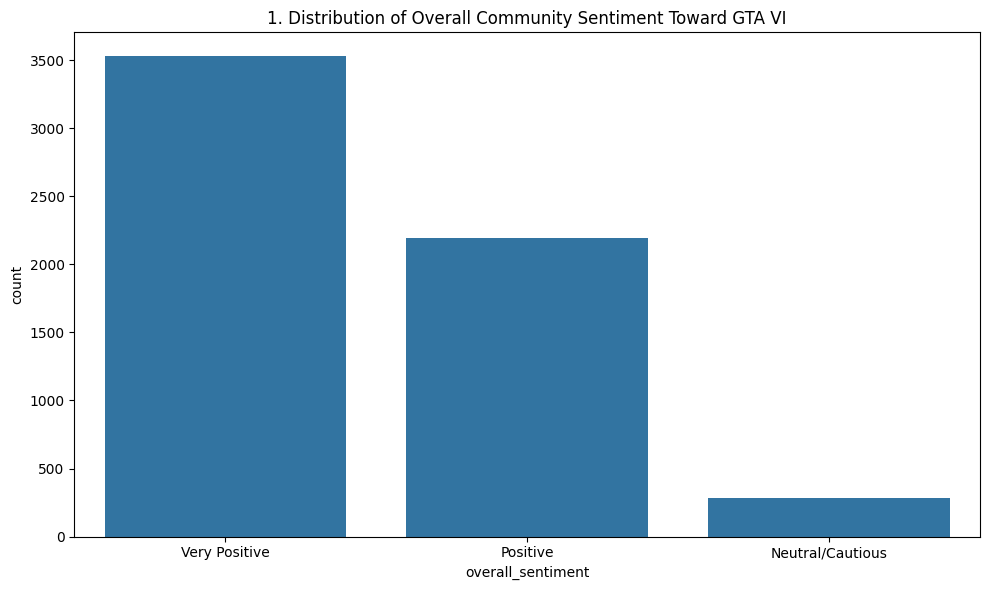

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='overall_sentiment', order=df['overall_sentiment'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Overall Community Sentiment Toward GTA VI')
show_fig()
plot_no += 1

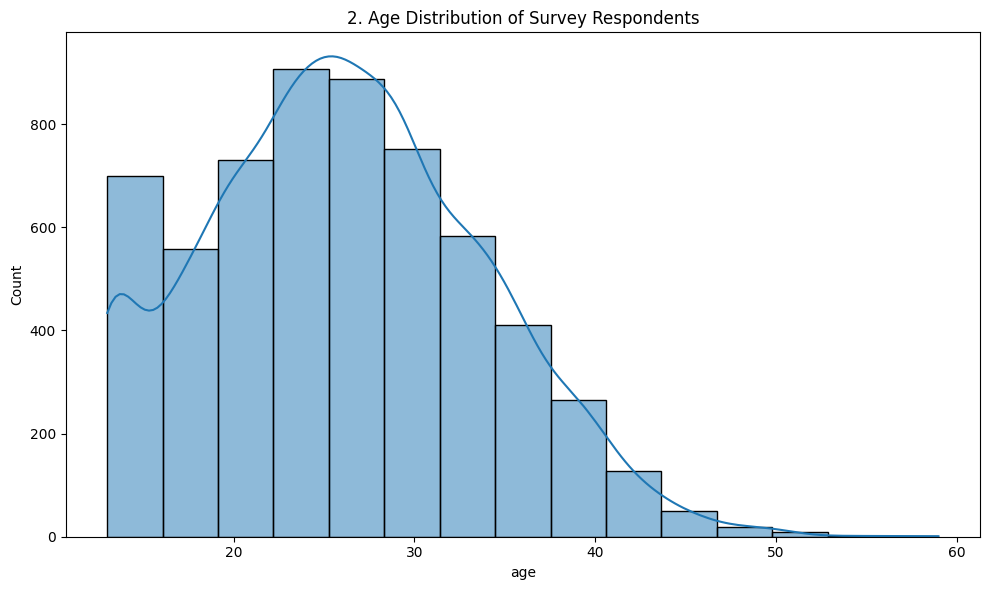

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=15, kde=True)
plt.title(f'{plot_no}. Age Distribution of Survey Respondents')
show_fig()
plot_no += 1

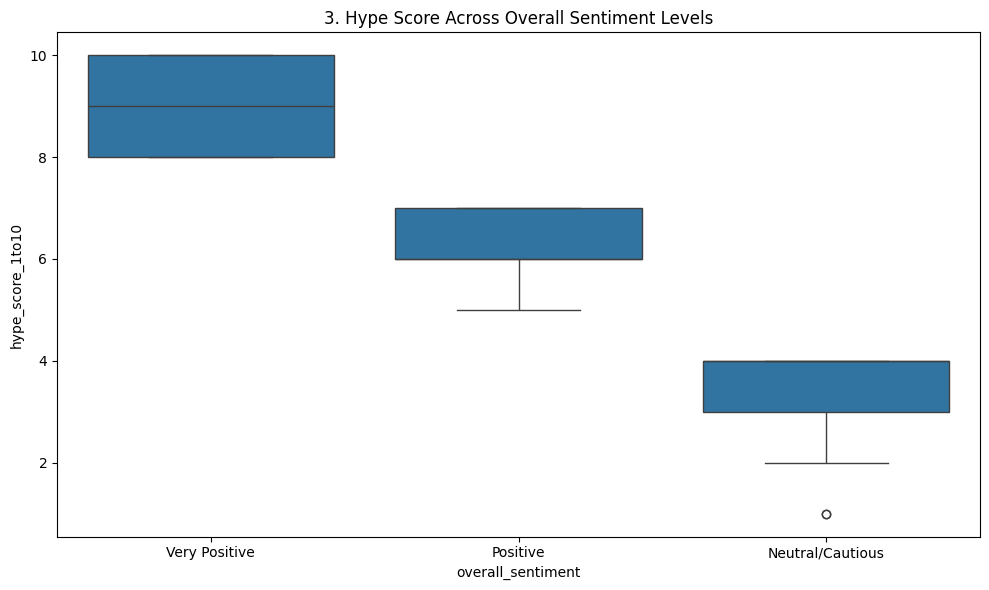

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='overall_sentiment', y='hype_score_1to10')
plt.title(f'{plot_no}. Hype Score Across Overall Sentiment Levels')
show_fig()
plot_no += 1

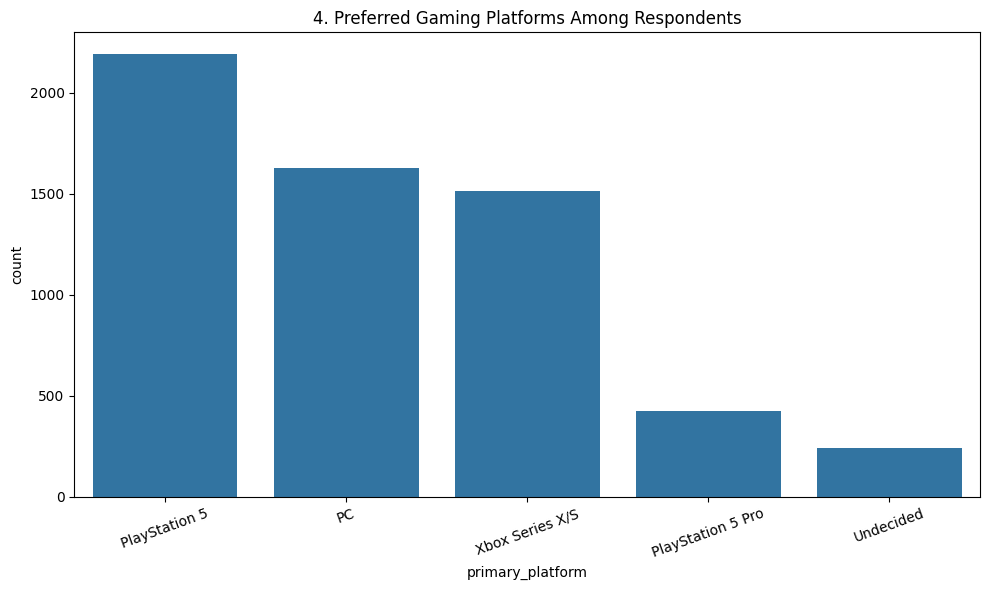

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='primary_platform', order=df['primary_platform'].value_counts().index)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Preferred Gaming Platforms Among Respondents')
show_fig()
plot_no += 1

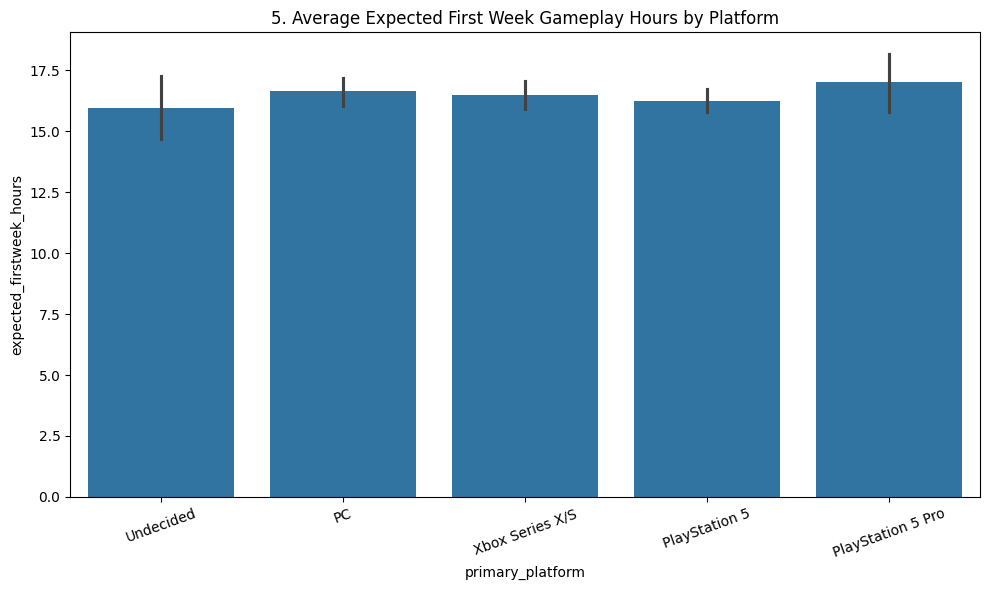

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='primary_platform', y='expected_firstweek_hours', estimator='mean')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Average Expected First Week Gameplay Hours by Platform')
show_fig()
plot_no += 1

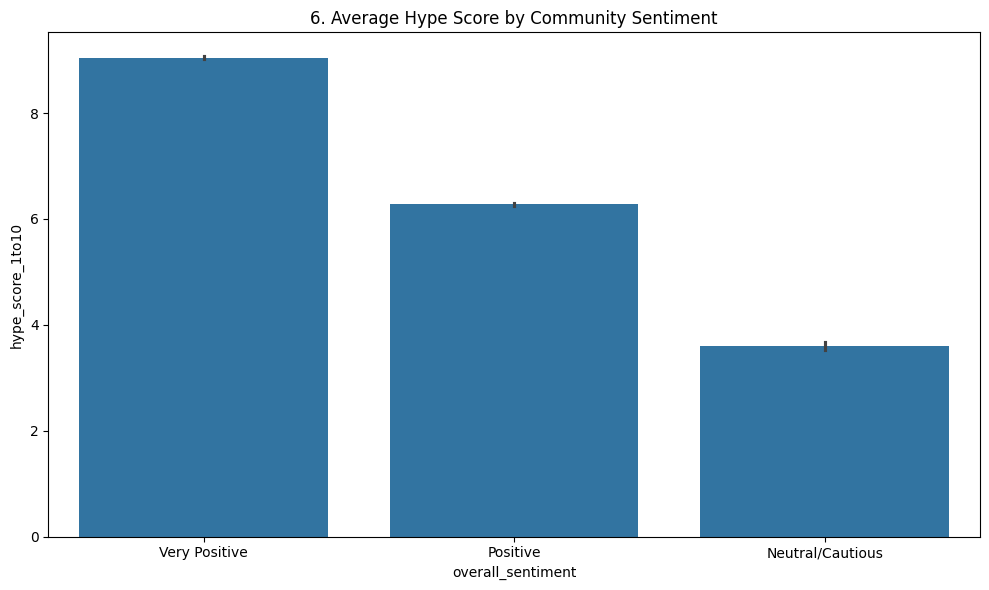

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='overall_sentiment', y='hype_score_1to10', estimator='mean')
plt.title(f'{plot_no}. Average Hype Score by Community Sentiment')
show_fig()
plot_no += 1

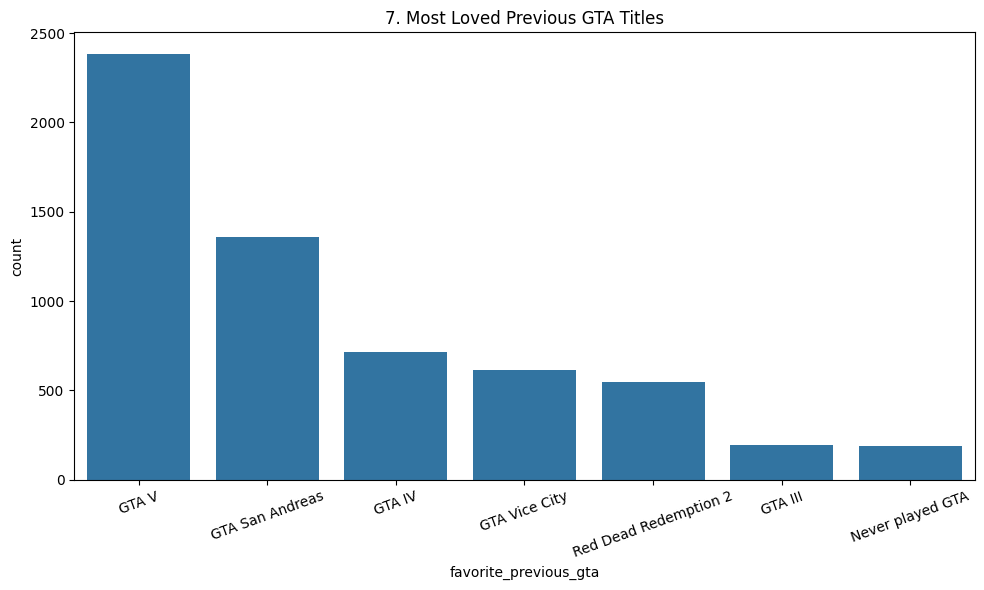

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='favorite_previous_gta', order=df['favorite_previous_gta'].value_counts().index)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Most Loved Previous GTA Titles')
show_fig()
plot_no += 1

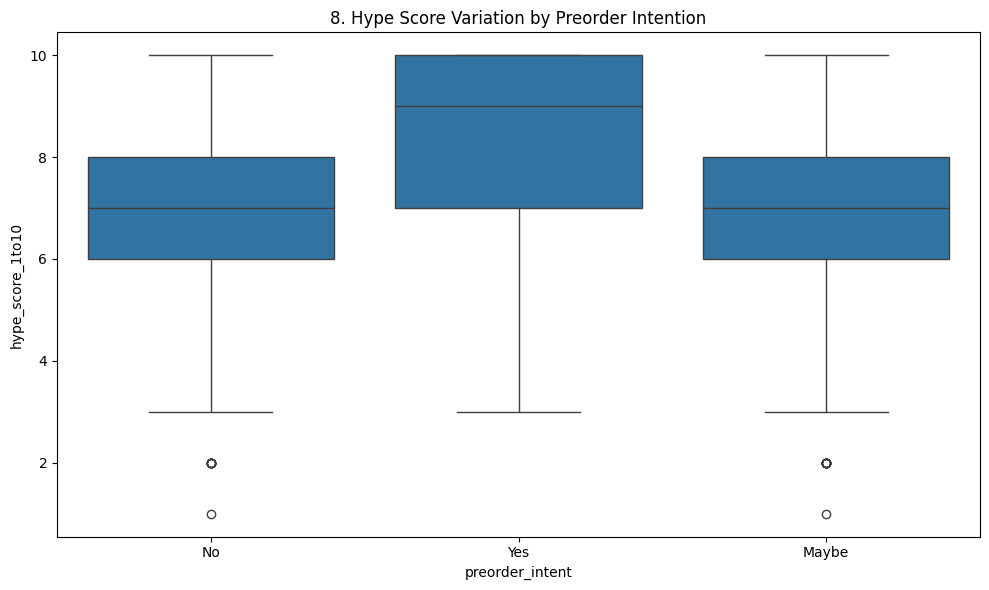

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='preorder_intent', y='hype_score_1to10')
plt.title(f'{plot_no}. Hype Score Variation by Preorder Intention')
show_fig()
plot_no += 1

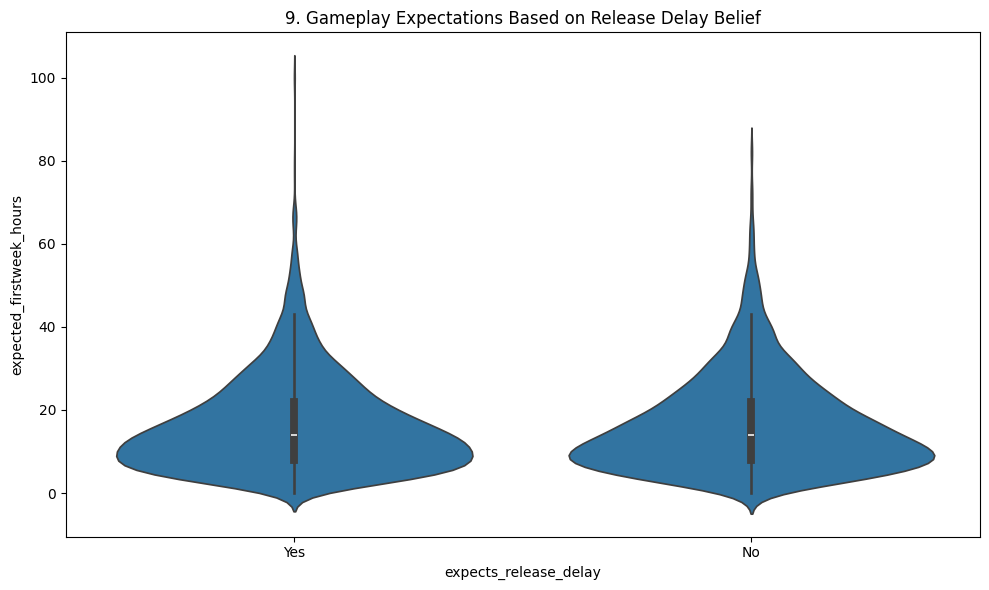

In [22]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='expects_release_delay', y='expected_firstweek_hours')
plt.title(f'{plot_no}. Gameplay Expectations Based on Release Delay Belief')
show_fig()
plot_no += 1

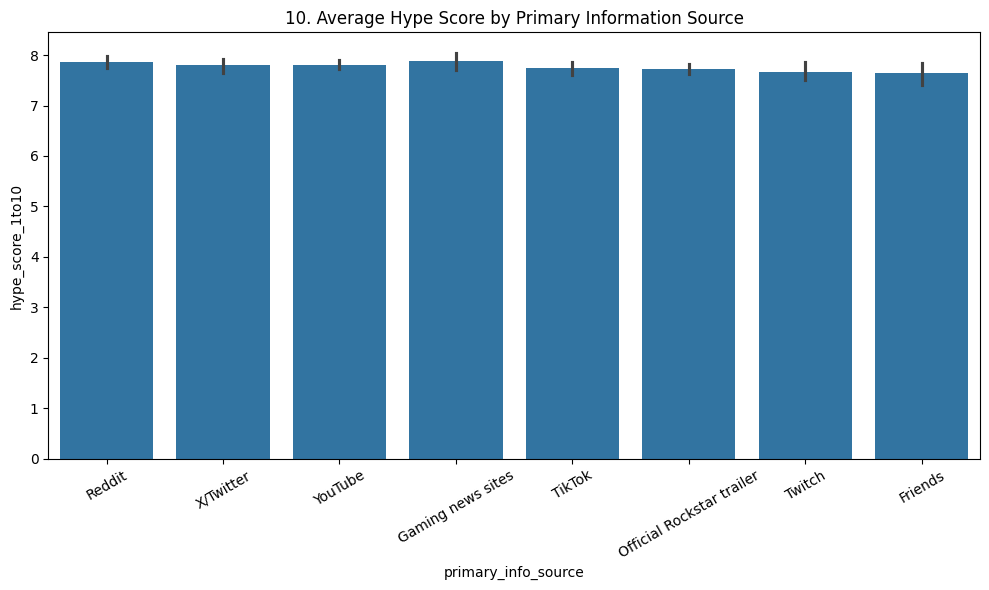

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='primary_info_source', y='hype_score_1to10', estimator='mean')
plt.xticks(rotation=30)
plt.title(f'{plot_no}. Average Hype Score by Primary Information Source')
show_fig()
plot_no += 1

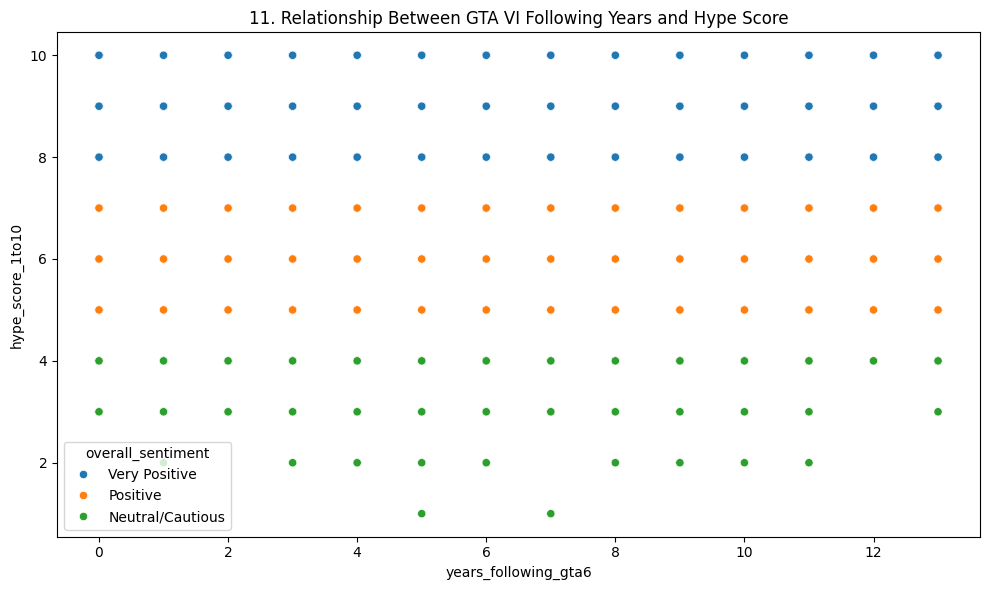

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_following_gta6', y='hype_score_1to10', hue='overall_sentiment')
plt.title(f'{plot_no}. Relationship Between GTA VI Following Years and Hype Score')
show_fig()
plot_no += 1

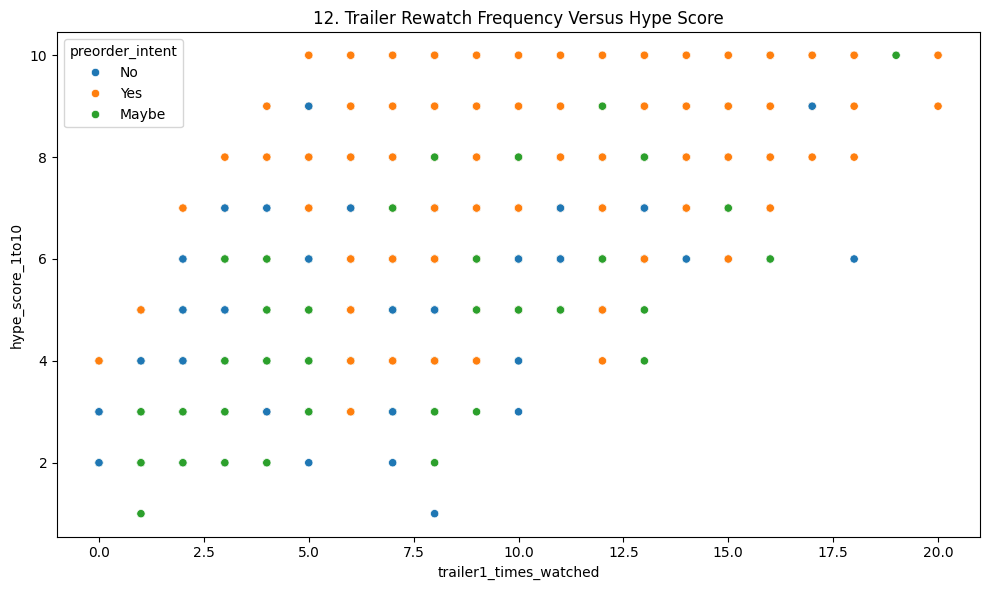

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='trailer1_times_watched', y='hype_score_1to10', hue='preorder_intent')
plt.title(f'{plot_no}. Trailer Rewatch Frequency Versus Hype Score')
show_fig()
plot_no += 1

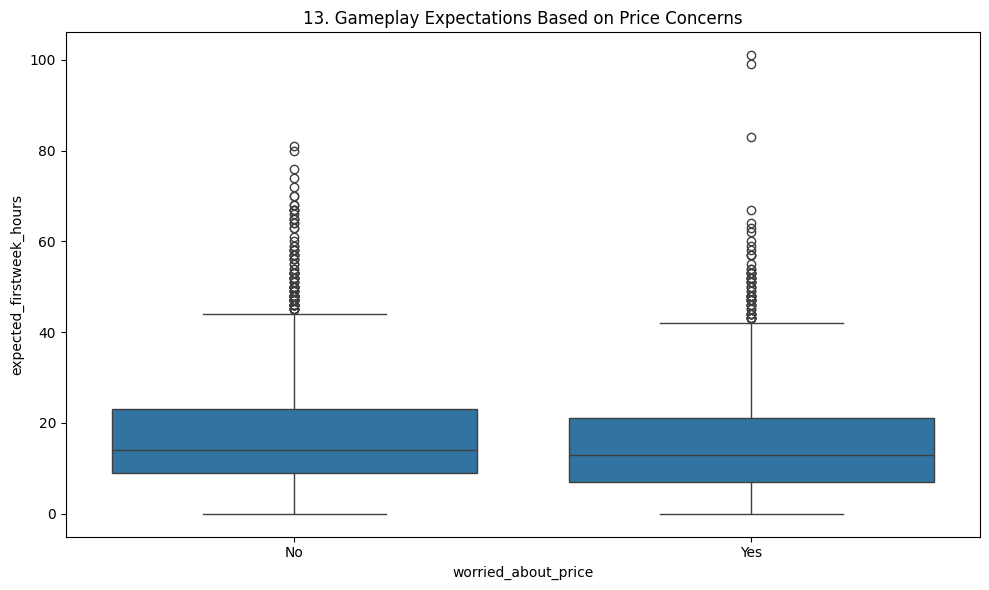

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='worried_about_price', y='expected_firstweek_hours')
plt.title(f'{plot_no}. Gameplay Expectations Based on Price Concerns')
show_fig()
plot_no += 1

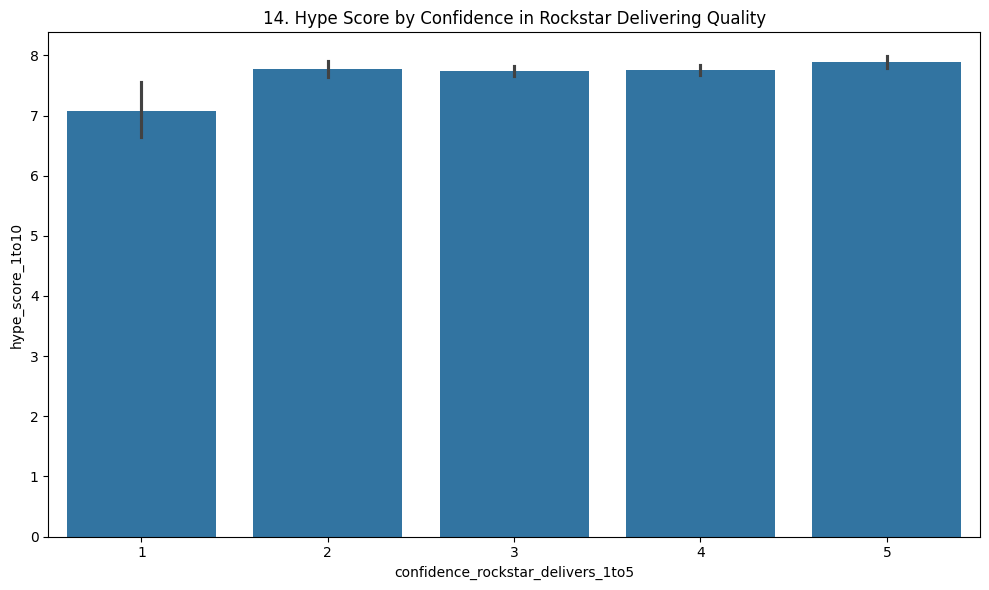

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='confidence_rockstar_delivers_1to5', y='hype_score_1to10', estimator='mean')
plt.title(f'{plot_no}. Hype Score by Confidence in Rockstar Delivering Quality')
show_fig()
plot_no += 1

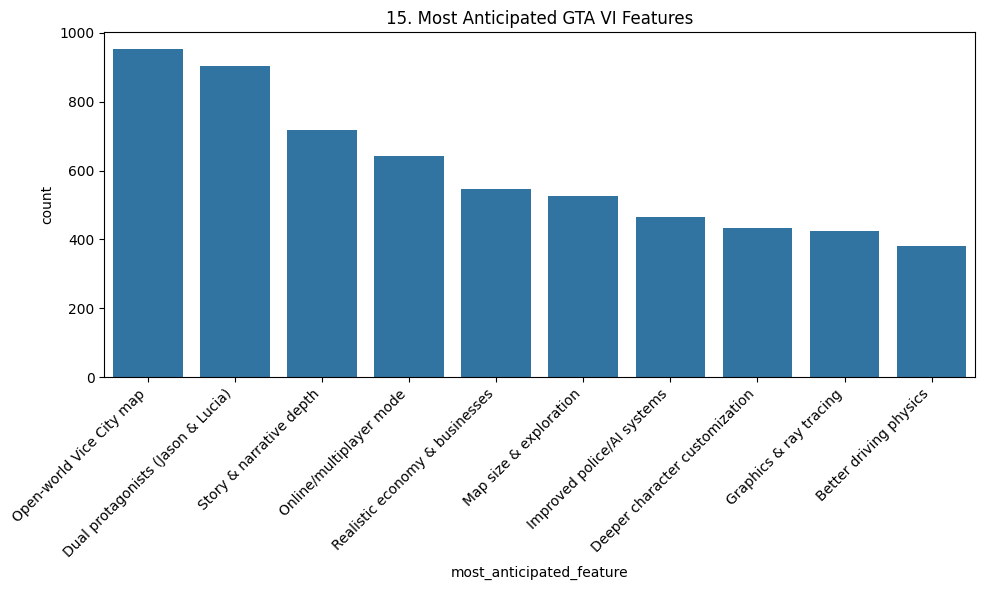

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='most_anticipated_feature', order=df['most_anticipated_feature'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title(f'{plot_no}. Most Anticipated GTA VI Features')
show_fig()
plot_no += 1

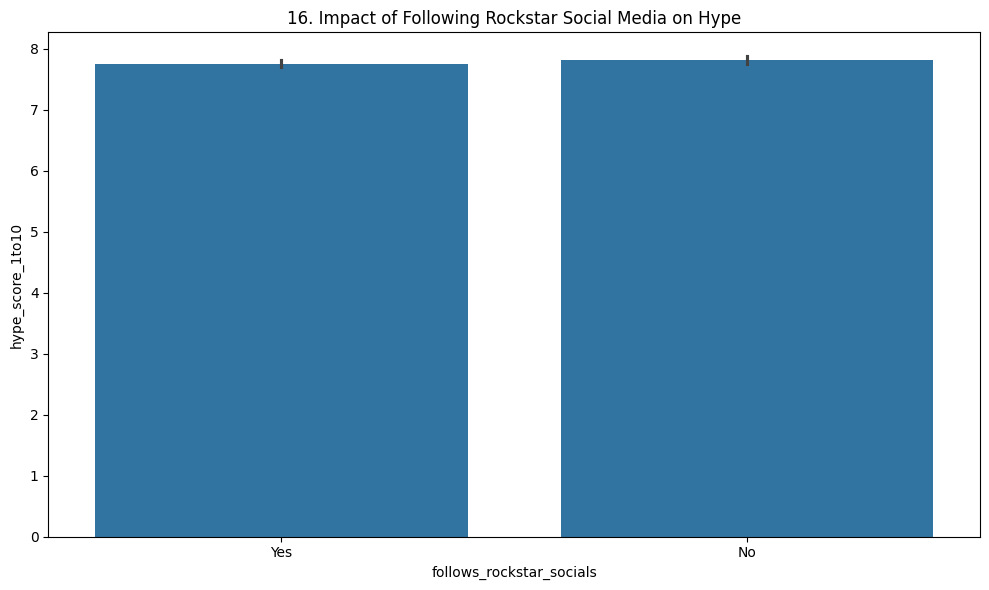

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='follows_rockstar_socials', y='hype_score_1to10', estimator='mean')
plt.title(f'{plot_no}. Impact of Following Rockstar Social Media on Hype')
show_fig()
plot_no += 1

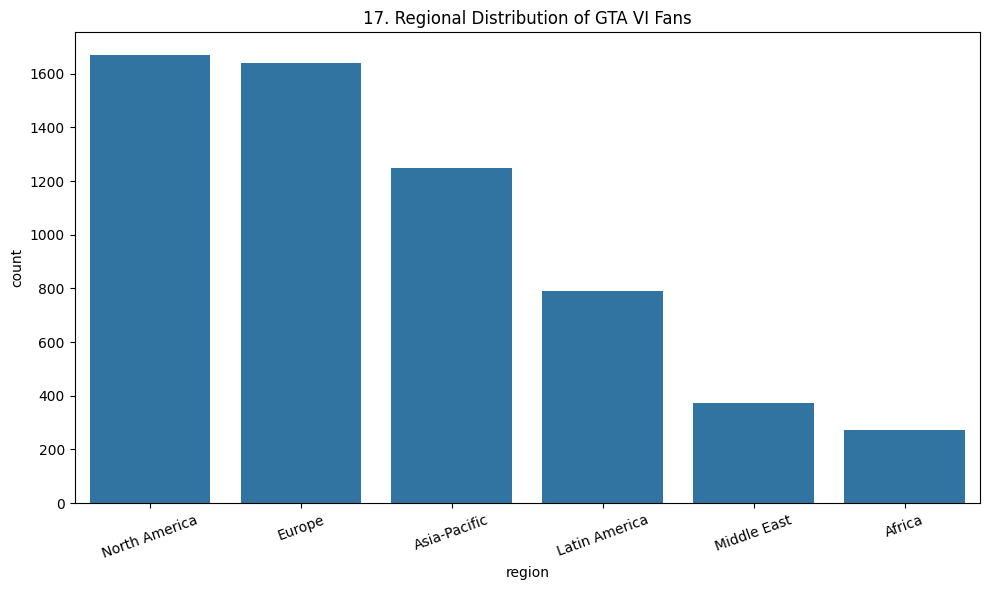

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Regional Distribution of GTA VI Fans')
show_fig()
plot_no += 1

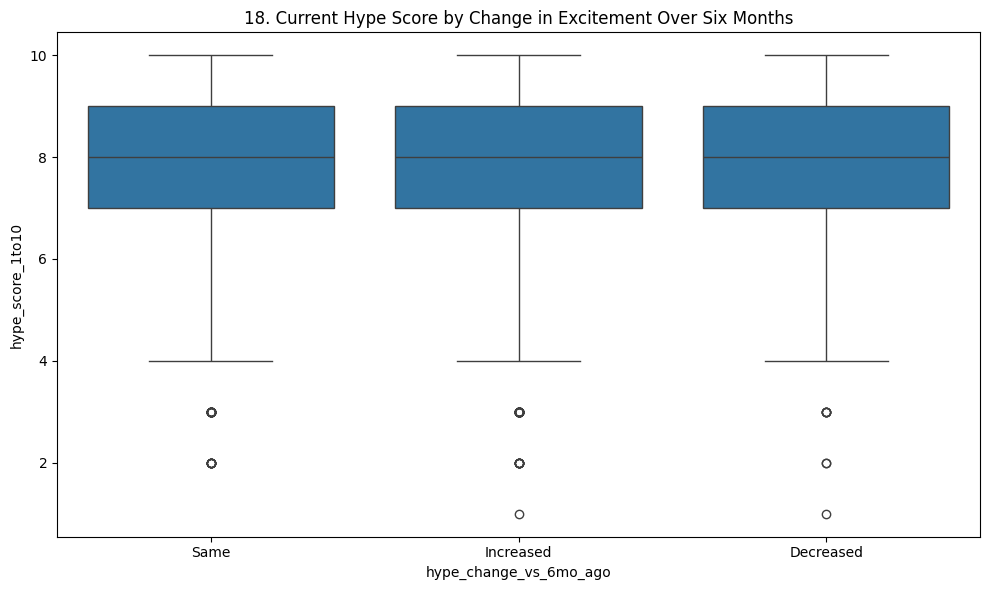

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='hype_change_vs_6mo_ago', y='hype_score_1to10')
plt.title(f'{plot_no}. Current Hype Score by Change in Excitement Over Six Months')
show_fig()
plot_no += 1

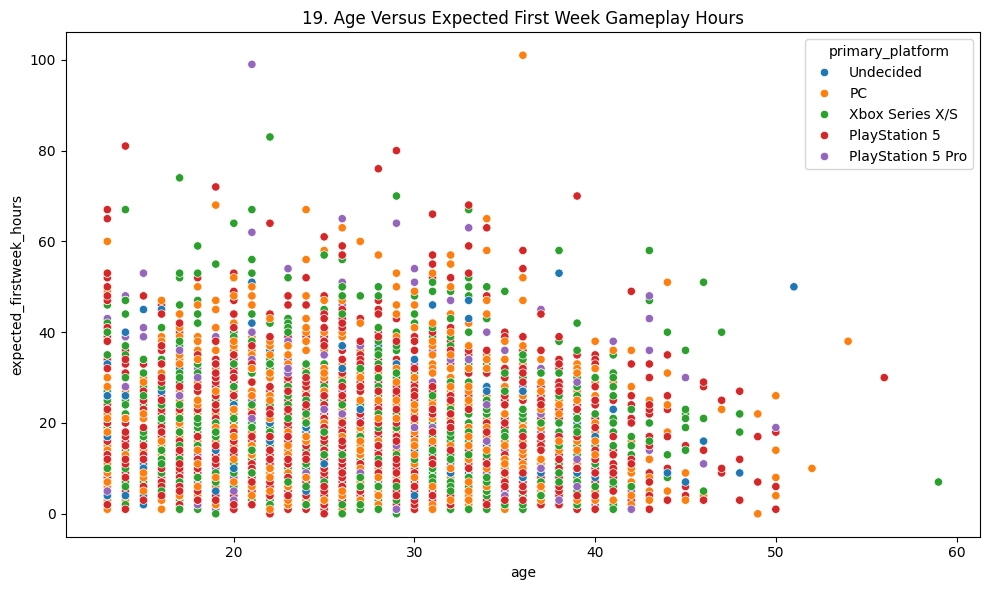

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='expected_firstweek_hours', hue='primary_platform')
plt.title(f'{plot_no}. Age Versus Expected First Week Gameplay Hours')
show_fig()
plot_no += 1

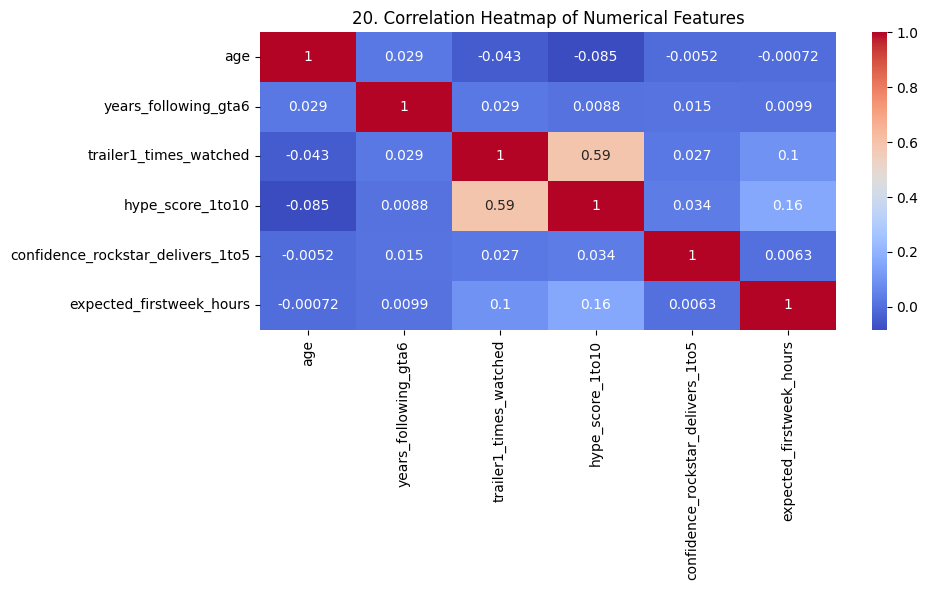

In [33]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [34]:
X = df.drop(columns=['respondent_id', 'overall_sentiment'])
y = df['overall_sentiment']

## Separate categorical and numerical columns

In [35]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

## Create preprocessing pipeline

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Split dataset into training and testing sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Build Support Vector Machine classification pipeline

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

## Train the model

In [39]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'years_following_gta6', 'trailer1_times_watched',
       'hype_score_1to10', 'confidence_rockstar_delivers_1to5',
       'expected_firstweek_hours'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['region', 'primary_platform', 'favorite_previous_gta',
       'primary_info_source', 'most_anticipated_feature', 'preorder_intent',
       'expects_release_delay', 'worried_about_price',
       'follows_rockstar_socials', 'hype_change_vs_6mo_ago'],
      dtype='object'))])),
                ('classifier', SVC(random_state=42))])

## Make predictions

In [40]:
y_pred = model.predict(X_test)

## Calculate and print accuracy

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {round(accuracy*100)}%")

Accuracy Score: 100%


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

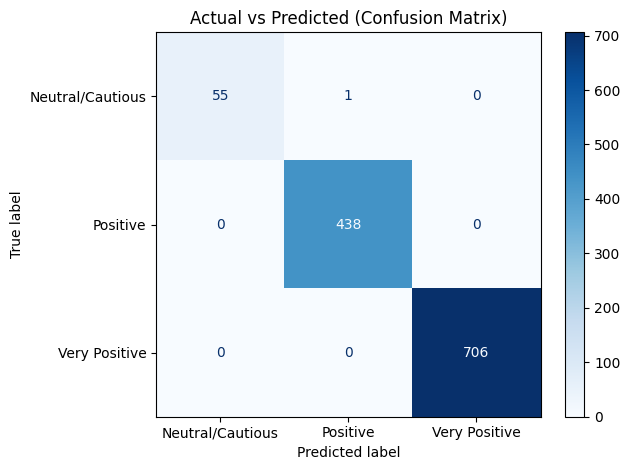

In [42]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()